In [54]:
import torch
import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
import os
import re
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchtext.vocab import GloVe
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


## Data collection

### Data description

#### Import dataset

In [2]:
path = r"..\data\IMDB Dataset.csv"
imdb_data = pd.read_csv(path)

#### Data description

In [3]:
imdb_data.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [4]:
imdb_data['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [5]:
word_counts = imdb_data['review'].apply(lambda x: len(x.split()))
word_counts.describe()

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review, dtype: float64

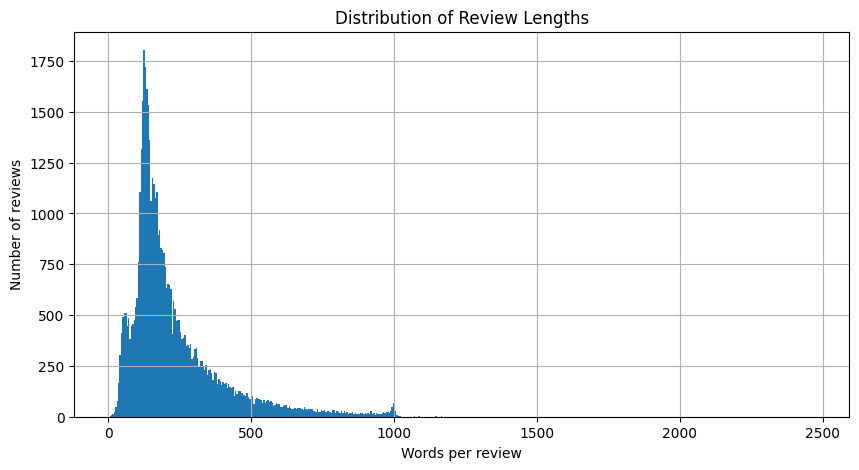

In [6]:
word_counts.hist(bins=500, figsize=(10,5))
plt.xlabel('Words per review')
plt.ylabel('Number of reviews')
plt.title('Distribution of Review Lengths')
plt.show()

### Data cleaning

#### Remove duplicates

In [7]:
imdb_data_clean = imdb_data.drop_duplicates()
imdb_data_clean.describe()

,review,sentiment
count,49582,49582
unique,49582,2
top,One of the other reviewers has mentioned that ...,positive
freq,1,24884


#### Remove HTML tags

In [8]:
def html_tags_cleaning(review : str):
    return re.sub(r"<.*?>", "", review)

imdb_data_clean['review'] = imdb_data_clean['review'].apply(html_tags_cleaning)
imdb_data_clean


C:\Users\Facundo\AppData\Local\Temp\ipykernel_18316\2000925089.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['review'] = imdb_data_clean['review'].apply(html_tags_cleaning)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


#### Change label to int (1 or 0)

In [9]:
imdb_data_clean['sentiment'] = imdb_data_clean['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
imdb_data_clean

C:\Users\Facundo\AppData\Local\Temp\ipykernel_18316\335119053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['sentiment'] = imdb_data_clean['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)


,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. The filming tec...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


#### Reviews to lowercase

In [10]:
imdb_data_clean['review'] = imdb_data_clean['review'].apply(lambda x: str.lower(x))
imdb_data_clean

C:\Users\Facundo\AppData\Local\Temp\ipykernel_18316\1640804236.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['review'] = imdb_data_clean['review'].apply(lambda x: str.lower(x))


,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. the filming tec...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1
...,...,...
49995,i thought this movie did a down right good job...,1
49996,"bad plot, bad dialogue, bad acting, idiotic di...",0
49997,i am a catholic taught in parochial elementary...,0
49998,i'm going to have to disagree with the previou...,0


#### Tokenize words

In [11]:
nltk.download("punkt")
nltk.download("punkt_tab")
imdb_data_clean['tokens'] = imdb_data_clean['review'].apply(lambda x: word_tokenize(x))
imdb_data_clean['tokens']

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
C:\Users\Facundo\AppData\Local\Temp\ipykernel_18316\590999925.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['tokens'] = imdb_data_clean['review'].apply(lambda x: word_tokenize(x))


0        [one, of, the, other, reviewers, has, mentione...
1        [a, wonderful, little, production, ., the, fil...
2        [i, thought, this, was, a, wonderful, way, to,...
3        [basically, there, 's, a, family, where, a, li...
4        [petter, mattei, 's, ``, love, in, the, time, ...
                               ...                        
49995    [i, thought, this, movie, did, a, down, right,...
49996    [bad, plot, ,, bad, dialogue, ,, bad, acting, ...
49997    [i, am, a, catholic, taught, in, parochial, el...
49998    [i, 'm, going, to, have, to, disagree, with, t...
49999    [no, one, expects, the, star, trek, movies, to...
Name: tokens, Length: 49582, dtype: object

#### Remove stop words

In [12]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
imdb_data_clean['tokens'] = imdb_data_clean['tokens'].apply(lambda x: [t for t in x if t.isalpha() and t not in stop_words])
imdb_data_clean['tokens']

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
C:\Users\Facundo\AppData\Local\Temp\ipykernel_18316\1025203691.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['tokens'] = imdb_data_clean['tokens'].apply(lambda x: [t for t in x if t.isalpha() and t not in stop_words])


0        [one, reviewers, mentioned, watching, oz, epis...
1        [wonderful, little, production, filming, techn...
2        [thought, wonderful, way, spend, time, hot, su...
3        [basically, family, little, boy, jake, thinks,...
4        [petter, mattei, love, time, money, visually, ...
                               ...                        
49995    [thought, movie, right, good, job, creative, o...
49996    [bad, plot, bad, dialogue, bad, acting, idioti...
49997    [catholic, taught, parochial, elementary, scho...
49998    [going, disagree, previous, comment, side, mal...
49999    [one, expects, star, trek, movies, high, art, ...
Name: tokens, Length: 49582, dtype: object

#### Lemmatization

In [13]:
nltk.download('punkt_tab')      
nltk.download('wordnet')    
nltk.download('omw-1.4') 
nltk.download('averaged_perceptron_tagger_eng')

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
    
def preprocess_text(tokens):
    pos_tags = pos_tag(tokens)
    return [lemmatizer.lemmatize(t, get_wordnet_pos(tag)) for t, tag in pos_tags]
    
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
imdb_data_clean['tokens'] = imdb_data_clean['tokens'].apply(preprocess_text)
imdb_data_clean['tokens']

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Facundo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
C:\Users\Facundo\AppData\Local\Temp\ipykernel_18316\1018893829.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

0        [one, reviewer, mention, watch, oz, episode, h...
1        [wonderful, little, production, film, techniqu...
2        [think, wonderful, way, spend, time, hot, summ...
3        [basically, family, little, boy, jake, think, ...
4        [petter, mattei, love, time, money, visually, ...
                               ...                        
49995    [think, movie, right, good, job, creative, ori...
49996    [bad, plot, bad, dialogue, bad, act, idiotic, ...
49997    [catholic, teach, parochial, elementary, schoo...
49998    [go, disagree, previous, comment, side, maltin...
49999    [one, expect, star, trek, movie, high, art, fa...
Name: tokens, Length: 49582, dtype: object

#### Pad and truncate

In [40]:
max_len = int(word_counts.mean())

def pad_or_truncate(seq, max_len, pad_value):
    if len(seq) > max_len:
        return seq[:max_len]
    else:
        return seq + [pad_value] * (max_len - len(seq))
    
imdb_data_clean['tokens'] = imdb_data_clean['tokens'].apply(lambda x: pad_or_truncate(x, max_len, ''))
imdb_data_clean['tokens']

C:\Users\Facundo\AppData\Local\Temp\ipykernel_18316\1641187855.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['tokens'] = imdb_data_clean['tokens'].apply(lambda x: pad_or_truncate(x, max_len, ''))


0        [one, reviewer, mention, watch, oz, episode, h...
1        [wonderful, little, production, film, techniqu...
2        [think, wonderful, way, spend, time, hot, summ...
3        [basically, family, little, boy, jake, think, ...
4        [petter, mattei, love, time, money, visually, ...
                               ...                        
49995    [think, movie, right, good, job, creative, ori...
49996    [bad, plot, bad, dialogue, bad, act, idiotic, ...
49997    [catholic, teach, parochial, elementary, schoo...
49998    [go, disagree, previous, comment, side, maltin...
49999    [one, expect, star, trek, movie, high, art, fa...
Name: tokens, Length: 49582, dtype: object

#### Get word embeddings

In [57]:
all_tokens = [token for review in imdb_data_clean['tokens'] for token in review if token != '']
counter = Counter(all_tokens)

vocab = {"<pad>": 0, "<unk>": 1}
for i, word in enumerate(counter.keys(), start=2):
    vocab[word] = i

pad_idx = vocab["<pad>"]
unk_idx = vocab["<unk>"]

def numericalize(tokens, vocab, pad_idx=0, unk_idx=1):
    return [vocab.get(token, unk_idx) if token != '' else pad_idx for token in tokens]

imdb_data_clean['tokens_idx'] = imdb_data_clean['tokens'].apply(lambda x: numericalize(x, vocab))
imdb_data_clean['tokens_idx']

C:\Users\Facundo\AppData\Local\Temp\ipykernel_18316\698219885.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imdb_data_clean['tokens_idx'] = imdb_data_clean['tokens'].apply(lambda x: numericalize(x, vocab))


0        [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 6...
1        [136, 137, 138, 139, 140, 141, 37, 142, 143, 1...
2        [196, 136, 197, 198, 199, 200, 201, 202, 203, ...
3        [257, 258, 137, 259, 260, 196, 261, 262, 263, ...
4        [293, 294, 295, 199, 296, 297, 298, 139, 5, 29...
                               ...                        
49995    [196, 265, 9, 350, 1082, 5808, 465, 12, 284, 6...
49996    [458, 207, 458, 209, 458, 349, 4623, 1471, 681...
49997    [8287, 2213, 67831, 12931, 724, 14772, 2213, 6...
49998    [21, 7580, 328, 484, 134, 5508, 2, 1366, 4816,...
49999    [2, 284, 477, 3846, 265, 56, 2189, 584, 284, 2...
Name: tokens_idx, Length: 49582, dtype: object

### Model

In [41]:
class SentimentCNN(nn.Module):
    def __init__(self, embedding_dim, num_classes=2):
        super().__init__()
        
        # 1D CNN layers with different kernel sizes (n-grams)
        self.conv1 = nn.Conv1d(in_channels=embedding_dim, out_channels=100, kernel_size=3)
        self.conv2 = nn.Conv1d(in_channels=embedding_dim, out_channels=100, kernel_size=4)
        self.conv3 = nn.Conv1d(in_channels=embedding_dim, out_channels=100, kernel_size=5)
        
        # Fully connected layer
        self.fc = nn.Linear(3 * 100, num_classes)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # Embed words: (batch_size, seq_len, embedding_dim)
        x = self.embedding(x)
        
        # CNN expects (batch_size, embedding_dim, seq_len)
        x = x.permute(0, 2, 1)
        
        # Apply convolution + ReLU + global max pooling
        x1 = F.relu(self.conv1(x)).max(dim=2)[0]
        x2 = F.relu(self.conv2(x)).max(dim=2)[0]
        x3 = F.relu(self.conv3(x)).max(dim=2)[0]
        
        # Concatenate pooled outputs
        x = torch.cat([x1, x2, x3], dim=1)
        x = self.dropout(x)
        
        # Fully connected layer
        logits = self.fc(x)
        return logits

In [59]:
class MovieReviewsDataset(Dataset):
    def __init__(self, dataset_frame : pd.DataFrame):
        self.reviews = dataset_frame['tokens_idx']
        self.labels = dataset_frame['sentiment']

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, idx):
        review_tensor = torch.tensor(self.reviews.iloc[idx])
        label_tensor = torch.tensor(self.labels.iloc[idx])
        return review_tensor, label_tensor

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mrd = MovieReviewsDataset(imdb_data_clean)

g = torch.manual_seed(49)
train_set, validation_set, test_set = random_split(mrd, [0.7, 0.15, 0.15], generator=g)

train_dataloader = DataLoader(train_set, batch_size=128, shuffle=True)
validation_dataloader = DataLoader(validation_set, batch_size=128, shuffle=False)
test_dataloader = DataLoader(test_set, batch_size=128, shuffle=False)

embedding_dim = 300
vec = GloVe(name="6B", dim=embedding_dim)
model = SentimentCNN(embedding_dim, num_classes=2).to(device)
model.embedding = nn.Embedding.from_pretrained(vec.vectors, freeze=False).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 100
best_val_loss = float("inf")
save_path = "sentiment_cnn.pt"

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_dataloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i+1):.3f}')
        running_loss = 0.0

    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in validation_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(validation_dataloader)
    val_acc = correct / total

    print(f"Epoch {epoch+1}/{epochs} "
          f"Train Loss: {running_loss/len(train_dataloader):.4f} "
          f"Val Loss: {avg_val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}")

    # ---- Save best model ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        print(f"Model improved. Saved to {save_path}")

[1,     1] loss: 0.702
[1,     2] loss: 0.365
[1,     3] loss: 0.243
[1,     4] loss: 0.178
[1,     5] loss: 0.143
[1,     6] loss: 0.116
[1,     7] loss: 0.098
[1,     8] loss: 0.086
[1,     9] loss: 0.076
[1,    10] loss: 0.074
[1,    11] loss: 0.063
[1,    12] loss: 0.058
[1,    13] loss: 0.057
[1,    14] loss: 0.055
[1,    15] loss: 0.046
[1,    16] loss: 0.040
[1,    17] loss: 0.040
[1,    18] loss: 0.036
[1,    19] loss: 0.036
[1,    20] loss: 0.034
[1,    21] loss: 0.031
[1,    22] loss: 0.029
[1,    23] loss: 0.028
[1,    24] loss: 0.028
[1,    25] loss: 0.027
[1,    26] loss: 0.025
[1,    27] loss: 0.024
[1,    28] loss: 0.024
[1,    29] loss: 0.021
[1,    30] loss: 0.023
[1,    31] loss: 0.020
[1,    32] loss: 0.020
[1,    33] loss: 0.019
[1,    34] loss: 0.018
[1,    35] loss: 0.019
[1,    36] loss: 0.017
[1,    37] loss: 0.016
[1,    38] loss: 0.016
[1,    39] loss: 0.016
[1,    40] loss: 0.014
[1,    41] loss: 0.016
[1,    42] loss: 0.014
[1,    43] loss: 0.014
[1,    44] 

KeyboardInterrupt: 